# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Muhamad Fachri Wijaya
- **Email:** fahririfkinaila@gmail.com
- **ID Dicoding:** fachri26

## Menentukan Pertanyaan Bisnis

- **Q1** - Di negara bagian (state) mana pelanggan paling banyak terkonsentrasi?
- **Q2** - Apa metode pembayaran yang paling populer digunakan oleh pelanggan?
- **Q3** - Bagaimana hubungan antara keterlambatan pengiriman dengan tingkat kepuasan pelanggan berdasarkan skor ulasan?
- **Q4** - Bagaimana segmentasi pelanggan berdasarkan perilaku pembelian mereka selama periode 2016–2018 menggunakan pendekatan RFM (Recency, Frequency, Monetary)?
- **Q5** - Bagaimana kontribusi masing-masing segmen pelanggan terhadap total revenue selama periode analisis?

Pertanyaan Q4 dan Q5 akan dibahas di analisis lanjutan.

## Import Semua Packages/Library yang Digunakan

In [377]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [378]:
base_url = "https://raw.githubusercontent.com/MFachriW/proyek-analisis-data/refs/heads/main/E-Commerce%20Public%20Dataset/"

In [379]:
orders_df = pd.read_csv(base_url + "orders_dataset.csv")
orders_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [380]:
customers_df = pd.read_csv(base_url + "customers_dataset.csv")
customers_df.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [381]:
products_df = pd.read_csv(base_url + "products_dataset.csv")
products_df.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [382]:
order_items_df = pd.read_csv(base_url + "order_items_dataset.csv")
order_items_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [383]:
order_payments_df = pd.read_csv(base_url + "order_payments_dataset.csv")
order_payments_df.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [384]:
order_reviews_df = pd.read_csv(base_url + "order_reviews_dataset.csv")
order_reviews_df.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [385]:
sellers_df = pd.read_csv(base_url + "sellers_dataset.csv")
sellers_df.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [386]:
geolocation_df = pd.read_csv(base_url + "geolocation_dataset.csv")
geolocation_df.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [387]:
product_category_df = pd.read_csv(base_url + "product_category_name_translation.csv")
product_category_df.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


**Insight:**
- Terdapat 9 dataset yang tersedia untuk dianalisis, mencakup berbagai dimensi transaksi e-commerce seperti data pelanggan, produk, penjual, kategori produk, data lokasi, serta detail pesanan (item, pembayaran, dan ulasan).
- Dataset tersebut disajikan dalam tabel terpisah. Integrasi data dilakukan menggunakan *primary key* unik (seperti `customer_id` dan `order_id`) untuk memungkinkan analisis dari sudut pandang perilaku pelanggan, performa operasional, dan tingkat kepuasan.
- Berdasarkan pertanyaan bisnis mengenai segmentasi **RFM (Recency, Frequency, Monetary)**, kontribusi **Revenue**, serta korelasi **Keterlambatan dengan Kepuasan**, maka tabel yang dipilih untuk analisis lebih lanjut adalah `orders_df`, `customers_df`, `order_payments_df`, dan `order_reviews_df`.

<br>

**Peran Masing-masing Tabel dalam Analisis:**

1. **`customers_df`**
   - Sebagai master data identitas pelanggan.
   - Digunakan untuk mengunci identitas unik melalui `customer_unique_id`. Karena satu orang hanya memiliki satu ID unik, tabel ini menjadi fondasi akurasi perhitungan segmen pelanggan pada **Q4** dan **Q5**. Selain itu, kolom `customer_state` pada tabel ini menjadi sumber data utama untuk memetakan persebaran geografis pelanggan (menjawab **Q1**).

2. **`orders_df`**
   - Sumber data log waktu pesanan dan status pengiriman.
   - Digunakan untuk menghitung *Recency* dan *Frequency* berdasarkan `order_purchase_timestamp` (**Q4**). Selain itu, tabel ini menyediakan data estimasi vs realita pengiriman untuk mengukur variabel "keterlambatan" (**Q3**).

3. **`order_payments_df`**
   - Sumber data nilai transaksi (finansial).
   - Menyediakan kolom `payment_value` yang krusial untuk menghitung metrik *Monetary* pada **Q4** serta total kontribusi pendapatan (*Revenue*) per segmen pelanggan pada **Q5**. Tabel ini juga memuat kolom `payment_type` yang digunakan untuk mengidentifikasi metode pembayaran yang paling diminati (menjawab **Q2**).

4. **`order_reviews_df`**
   - **Peran:** Sumber metrik kepuasan pelanggan.
   - **Kaitan Bisnis:** Menyediakan data `review_score` yang akan dikorelasikan dengan data keterlambatan dari `orders_df`. Tabel ini menjawab **Q3** mengenai sejauh mana masalah logistik memengaruhi persepsi pelanggan.

### Assessing Data

#### Menilai tabel `orders_df`

In [388]:
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


Beberapa kolom yang berupa tanggal dan waktu masih bertipe object. Kolom-kolom tersebut akan langsung dikonversi menjadi datetime di tahap ini agar dapat langsung didescribe sesuai tipe datanya.

In [389]:
# Definisikan kategori kolom yang berupa tanggal
date_cols_orders_df = [
    'order_purchase_timestamp', 'order_approved_at',
    'order_delivered_carrier_date', 'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

# Konversi tipe data untuk kelompok Datetime
for col in date_cols_orders_df:
    orders_df[col] = pd.to_datetime(orders_df[col])

# Cek tipe data
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


In [390]:
orders_df.isna().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


Terdapat missing `order_approved_at` (160), `order_delivered_carrier_date` (1783), dan `order_delivered_customer_date` (2965). Karena jumlahnya sangat kecil dibandingkan total keseluruhan data (99441), membuang baris yang memiliki nilai missing ini masih relatif aman.

In [391]:
print("Jumlah duplikasi: ", orders_df.duplicated().sum())

Jumlah duplikasi:  0


In [392]:
orders_df.describe()

,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99281,97658,96476,99441
mean,2017-12-31 08:43:12.776581120,2017-12-31 18:35:24.098800128,2018-01-04 21:49:48.138278656,2018-01-14 12:09:19.035542272,2018-01-24 03:08:37.730111232
min,2016-09-04 21:15:19,2016-09-15 12:16:38,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-09-30 00:00:00
25%,2017-09-12 14:46:19,2017-09-12 23:24:16,2017-09-15 22:28:50.249999872,2017-09-25 22:07:22.249999872,2017-10-03 00:00:00
50%,2018-01-18 23:04:36,2018-01-19 11:36:13,2018-01-24 16:10:58,2018-02-02 19:28:10.500000,2018-02-15 00:00:00
75%,2018-05-04 15:42:16,2018-05-04 20:35:10,2018-05-08 13:37:45,2018-05-15 22:48:52.249999872,2018-05-25 00:00:00
max,2018-10-17 17:30:18,2018-09-03 17:40:06,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-11-12 00:00:00


Pada dataset ini, semua tanggal berada dalam rentang yang valid (2016-2018). Pengecekan outlier akan dilakukan pada kolom baru "delivery_duration" yang menilai durasi pengiriman sejak barang dipesan.

In [393]:
delivery_duration = orders_df['order_delivered_customer_date'] - orders_df['order_purchase_timestamp']
orders_df['delivery_duration'] = delivery_duration.dt.days
orders_df['delivery_duration'] = orders_df['delivery_duration'].astype('Int64')

orders_df.describe()

,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_duration
count,99441,99281,97658,96476,99441,96476.0
mean,2017-12-31 08:43:12.776581120,2017-12-31 18:35:24.098800128,2018-01-04 21:49:48.138278656,2018-01-14 12:09:19.035542272,2018-01-24 03:08:37.730111232,12.094086
min,2016-09-04 21:15:19,2016-09-15 12:16:38,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-09-30 00:00:00,0.0
25%,2017-09-12 14:46:19,2017-09-12 23:24:16,2017-09-15 22:28:50.249999872,2017-09-25 22:07:22.249999872,2017-10-03 00:00:00,6.0
50%,2018-01-18 23:04:36,2018-01-19 11:36:13,2018-01-24 16:10:58,2018-02-02 19:28:10.500000,2018-02-15 00:00:00,10.0
75%,2018-05-04 15:42:16,2018-05-04 20:35:10,2018-05-08 13:37:45,2018-05-15 22:48:52.249999872,2018-05-25 00:00:00,15.0
max,2018-10-17 17:30:18,2018-09-03 17:40:06,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-11-12 00:00:00,209.0
std,NaN,NaN,NaN,NaN,NaN,9.551746


In [394]:
orders_df.isna().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0
delivery_duration,2965


Secara umum, berdasarkan fungsi describe, nilai minimum `delivery_duration` ada di 0 hari (tiba di hari yang sama) dan maksimum di 209 hari.

Karena dalam pembuatan kolom `delivery_duration` terdapat beberapa nilai null pada `order_purchase_timestamp` dan `order_delivered_customer_date`, akan terdapat value NaT pada kolom `delivery_duration` (dalam hal ini terdapat 2979 missing value), sehingga harus dibersihkan terlebih dahulu sebelum dicek outliernya. Outlier pada `delivery_duration` juga merupakan informasi yang penting untuk menilai keterlambatan sehingga tidak akan langsung di hapus.

In [395]:
# Buang nilai NaT/NaN khusus untuk perhitungan outlier
clean_delivery_days = delivery_duration.dropna()

# Menghitung Q1, Q3, dan IQR
Q1_del = clean_delivery_days.quantile(0.25)
Q3_del = clean_delivery_days.quantile(0.75)
IQR_del = Q3_del - Q1_del

# Menentukan batas
lower_del = Q1_del - (1.5 * IQR_del)
upper_del = Q3_del + (1.5 * IQR_del)

# Mencari outlier menggunakan filtering Pandas (lebih aman dari loop)
outliers_delivery = clean_delivery_days[(clean_delivery_days < lower_del) |
                                        (clean_delivery_days > upper_del)]

print(f"Batas Atas: {upper_del.days} hari")
print(f"Jumlah Outlier: {len(outliers_delivery)}")

Batas Atas: 29 hari
Jumlah Outlier: 4899


In [396]:
orders_df[orders_df['delivery_duration'] > 150].head(10)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_duration
11399,47b40429ed8cce3aee9199792275433f,cb2caaaead400c97350c37a3fc536867,delivered,2018-01-03 09:44:01,2018-01-03 10:31:15,2018-02-06 01:48:28,2018-07-13 20:51:31,2018-01-19,191
19590,ca07593549f1816d26a572e06dc1eab6,75683a92331068e2d281b11a7866ba44,delivered,2017-02-21 23:31:27,2017-02-23 02:35:15,2017-03-08 13:47:46,2017-09-19 14:36:39,2017-03-22,209
29265,6e6527028de694ccade37f5a15a6d84a,a48d74b7c46f9ee06e4ca93cae7b598f,delivered,2017-11-25 23:51:54,2017-11-25 23:59:27,2017-11-28 17:11:21,2018-05-10 00:06:20,2017-12-18,165
29519,4fbc8d6f2f4db3e789d5a876fa349b56,bf391aa5a48fbaee55092f1993be3926,delivered,2018-02-02 21:38:36,2018-02-03 20:10:18,2018-02-08 01:04:18,2018-07-20 23:37:50,2018-03-08,168
31228,dfe5f68118c2576143240b8d78e5940a,8f6ceed676a529b29619a598b377de08,delivered,2017-03-17 12:32:22,2017-03-17 12:32:22,2017-03-21 18:28:04,2017-09-19 18:13:19,2017-04-19,186
37973,df6d8b7768a047c2981bae0a24afbb01,2da8c3c9c24c362231c8724105c23404,delivered,2017-04-04 10:46:22,2017-04-04 10:55:24,2017-04-05 15:24:20,2017-09-19 15:08:19,2017-05-10,168
38509,0f4519c5f1c541ddec9f21b3bddd533a,1a8a4a30dc296976717f44e7801fdeef,delivered,2017-03-09 13:26:57,2017-03-09 13:26:57,2017-03-22 05:28:14,2017-09-19 14:38:21,2017-04-11,194
40847,d24e8541128cea179a11a65176e0a96f,beeda72b31be3b8a38b5c2b77d7705c4,delivered,2017-06-12 13:14:11,2017-06-12 13:25:11,2017-06-16 14:44:37,2017-12-04 18:36:29,2017-06-26,175
49984,031e7d4e559a1bf08e71a419aa998d0a,aedfc62ab52a3e4ea642220ccdec91ff,delivered,2017-04-06 12:59:46,2017-04-06 13:10:41,2017-04-07 12:43:24,2017-09-19 16:23:52,2017-05-19,166
54480,2d7561026d542c8dbd8f0daeadf67a43,8199345f57c6d1cbe9701f92481beb8d,delivered,2017-03-15 11:24:27,2017-03-15 11:24:27,2017-03-16 09:29:16,2017-09-19 14:38:18,2017-04-13,188


Setelah di cek, ternyata banyak di antara yang durasi pengirimannya sangat lama (dalam hal ini diambil contoh > 150 hari) memiliki tanggal tiba (`order_delivered_customer_date`) yang jauh dari estimasi (`order_estimated_delivery_date`). Keterlambatan ini akan dianalisis hubungannya dengan skor ulasan.

#### Menilai tabel `customers_df`

In [397]:
customers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


Semua kolom kecuali `customer_zip_code_prefix` memiliki tipe data yang sesuai. `customer_zip_code_prefix` berisi kode pos yang sebaiknya dianggap sebagai string agar tidak kehilangan leading zero.

In [398]:
# Mengecek jumlah duplikat dari masing-masing customer_id dan customer_unique_id
print("Jumlah duplikasi customer_id: ", customers_df.duplicated(subset=['customer_id']).sum())
print("Jumlah duplikasi customer_unique_id: ", customers_df.duplicated(subset=['customer_unique_id']).sum())

Jumlah duplikasi customer_id:  0
Jumlah duplikasi customer_unique_id:  3345


Dari sini, diketahui bahwa setiap pelanggan (customer_unique_id) memiliki beberapa customer_id yang digunakan saat memesan barang. Setiap pesanan (order_id) terhubung oleh satu customer_id yang unik, dan satu customer_unique_id dapat memiliki beberapa customer_id.

In [399]:
customers_df.isna().sum()

,0
customer_id,0
customer_unique_id,0
customer_zip_code_prefix,0
customer_city,0
customer_state,0


In [400]:
print("Jumlah duplikasi: ", customers_df.duplicated().sum())

Jumlah duplikasi:  0


In [401]:
customers_df.describe()

,customer_zip_code_prefix
count,99441.000000
mean,35137.474583
std,29797.938996
min,1003.000000
25%,11347.000000
50%,24416.000000
75%,58900.000000
max,99990.000000


Dataset ini relatif bersih, dan tidak dilakukan pengecekan outlier karena sifatnya yang berupa string/object. Tipe data kode pos akan disesuaikan.

#### Menilai tabel `order_payments_df`

In [402]:
order_payments_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


Tipe data sudah benar untuk masing-masing kolom.

In [403]:
order_payments_df.isna().sum()

,0
order_id,0
payment_sequential,0
payment_type,0
payment_installments,0
payment_value,0


In [404]:
order_payments_df['payment_type'].value_counts()

,count
payment_type,
credit_card,76795
boleto,19784
voucher,5775
debit_card,1529
not_defined,3


Meskipun melalui pengecekan isna tidak ada yang missing, ternyata ada kategori pembayaran yang not_defined sebanyak 3 buah. Kategori ini kita anggap sebagai missing juga.

In [405]:
print("Jumlah duplikasi: ", order_payments_df.duplicated().sum())

Jumlah duplikasi:  0


In [406]:
order_payments_df.describe()

,payment_sequential,payment_installments,payment_value
count,103886.000000,103886.000000,103886.000000
mean,1.092679,2.853349,154.100380
std,0.706584,2.687051,217.494064
min,1.000000,0.000000,0.000000
25%,1.000000,1.000000,56.790000
50%,1.000000,1.000000,100.000000
75%,1.000000,4.000000,171.837500
max,29.000000,24.000000,13664.080000


In [407]:
kolom_numerik = order_payments_df.select_dtypes(include=['number']).columns

# Loop untuk menghitung outlier tiap kolom
for col in kolom_numerik:
    Q1 = order_payments_df[col].quantile(0.25)
    Q3 = order_payments_df[col].quantile(0.75)
    IQR = Q3 - Q1

    upper_bound = Q3 + (1.5 * IQR)
    lower_bound = Q1 - (1.5 * IQR)

    outliers_count = ((order_payments_df[col] < lower_bound) | (order_payments_df[col] > upper_bound)).sum()

    print(f"Kolom: {col}")
    print(f" - Batas Atas: {upper_bound:.2f}")
    print(f" - Jumlah Outlier: {outliers_count}")
    print("-" * 30)

Kolom: payment_sequential
 - Batas Atas: 1.00
 - Jumlah Outlier: 4526
------------------------------
Kolom: payment_installments
 - Batas Atas: 8.50
 - Jumlah Outlier: 6313
------------------------------
Kolom: payment_value
 - Batas Atas: 344.41
 - Jumlah Outlier: 7981
------------------------------


In [408]:
# Menunjukkan data yang payment_sequential nya > 20
order_payments_df[order_payments_df['payment_sequential'] > 20]

,order_id,payment_sequential,payment_type,payment_installments,payment_value
4885,fa65dad1b0e818e3ccc5cb0e39231352,27,voucher,1,66.02
24879,fa65dad1b0e818e3ccc5cb0e39231352,25,voucher,1,3.68
27824,285c2e15bebd4ac83635ccc563dc71f4,22,voucher,1,1.05
32393,ccf804e764ed5650cd8759557269dc13,26,voucher,1,23.10
39108,fa65dad1b0e818e3ccc5cb0e39231352,29,voucher,1,19.26
39111,fa65dad1b0e818e3ccc5cb0e39231352,28,voucher,1,29.05
39132,ccf804e764ed5650cd8759557269dc13,25,voucher,1,1.53
46437,895ab968e7bb0d5659d16cd74cd1650c,21,voucher,1,0.28
51816,ccf804e764ed5650cd8759557269dc13,24,voucher,1,2.79
53622,ccf804e764ed5650cd8759557269dc13,22,voucher,1,1.06


Pada payment_sequential, batas atas yang didapatkan adalah 1. Hal ini membuat nilai di atas angka 1 adalah outlier. Setelah ditelusuri lebih lanjut, nilai payment_sequential yang mencapai 29 ternyata kebanyakan **menggunakan voucher**, sehingga dapat disimpulkan bahwa jumlah pembayaran tersebut masih bisa dianggap nilai nyata karena banyak voucher yang digunakan dianggap sebagai payment sequential yang berbeda.

Pada payment_installment, nilai yang mencapai 24 juga masih dianggap nilai nyata, karena dalam mekanisme pembayaran, terdapat pilihan untuk mencicil sebanyak 24 kali.

Pada payment_value, juga terdapat outlier. Namun, data tersebut diputuskan untuk tetap dipertahankan karena mencerminkan transaksi nyata dengan nilai tinggi yang penting dalam perhitungan total revenue (Q2).

Pada payment_type, terdapat kategori not_defined yang dianggap sebagai nilai missing.

**Kesimpulan**
- Akan dilakukan dropping pada baris dengan payment_type not_defined

#### Menilai tabel `order_reviews_df`

In [409]:
order_reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


Kolom yang relevan (review_score, order_id) sudah memiliki tipe data yang sesuai.

In [410]:
order_reviews_df.isna().sum()

,0
review_id,0
order_id,0
review_score,0
review_comment_title,87656
review_comment_message,58247
review_creation_date,0
review_answer_timestamp,0


Terdapat 87656 nilai missing pada review_comment_title, dan 58247 nilai missing pada review_comment_message. Karena analisis ini tidak akan membahas isi dari komentar ulasan melainkan hanya membahas nilai ulasannya, dan rating_score tanpa komentar juga merupakan hal yang lazim, maka nilai missing ini tidak akan dibuang atau diproses.

In [411]:
print("Jumlah duplikasi: ", order_reviews_df.duplicated().sum())

Jumlah duplikasi:  0


In [412]:
order_reviews_df.describe()

,review_score
count,99224.000000
mean,4.086421
std,1.347579
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


**Insight:**

Secara keseluruhan, dataset memiliki struktur yang baik untuk menjawab tiga pertanyaan bisnis utama. Namun, terdapat beberapa temuan krusial terkait kualitas data yang perlu diperhatikan:

 **1. Tabel `orders_df` (Logistik & Efisiensi)**
* **Tipe Data:** Kolom waktu (`order_purchase_timestamp`, dll.) awalnya bertipe `object` dan telah dikonversi menjadi `datetime` untuk memungkinkan perhitungan durasi.
* **Missing Values:** Terdapat 2.965 data kosong pada `order_delivered_customer_date`. Hal ini teridentifikasi sebagai pesanan yang belum selesai atau dibatalkan.
* **Outlier Durasi Pengiriman:** Berdasarkan perhitungan $IQR$, batas atas pengiriman normal adalah **29 hari**. Ditemukan **4.899 data outlier** (termasuk kasus ekstrem **209 hari**) yang akan dipertahankan untuk menganalisis hubungan keterlambatan dengan kepuasan pelanggan pada **Q3**.

 **2. Tabel `customers_df` (Identitas & Loyalitas)**
* **Integritas Kode Pos:** Kolom `customer_zip_code_prefix` bertipe numerik yang berisiko menghilangkan *leading zero*. Diperlukan standarisasi menjadi 5 digit string agar tidak kehilangan informasi lokasi.
* **Indikasi Loyalitas:** Adanya selisih antara `customer_unique_id` (96.096) dan `customer_id` (99.441) menunjukkan adanya pelanggan yang melakukan pembelian berulang, yang akan menjadi dasar analisis **Frequency** pada **Q1**.

 **3. Tabel `order_payments_df` (Finansial)**
* **Outlier Nilai Transaksi:** Ditemukan **7.981 outlier** pada `payment_value` dengan nilai hingga **13.664**. Data ini tetap dipertahankan karena merupakan transaksi nyata yang penting untuk perhitungan total *Revenue* pada **Q2**.
* **Anomali Metode Pembayaran:** Nilai `payment_sequential` yang mencapai 29 divalidasi sebagai penggunaan banyak voucher dalam satu pesanan, bukan merupakan kesalahan sistem.

 **4. Tabel `order_reviews_df` (Kepuasan Pelanggan)**
* **Ketersediaan Data:** Meskipun terdapat banyak *missing values* pada pesan komentar (>50%), kolom `review_score` sepenuhnya terisi (99.224 data), sehingga sangat memadai untuk analisis korelasi pada **Q3**.

**Kesimpulan untuk Tahap Cleaning:**
Pembersihan akan difokuskan pada penanganan *missing values* di tabel pesanan, sementara data pencilan (*outlier*) durasi dan harga akan tetap diikutsertakan dalam analisis untuk menjaga objektivitas hasil bisnis.

### Cleaning Data

#### Membersihkan tabel `orders_df`

##### Missing values

In [413]:
orders_df = orders_df.dropna(subset=[
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date'
])

print("Jumlah missing values setelah dropna:")
print(orders_df.isna().sum())

Jumlah missing values setelah dropna:
order_id                         0
customer_id                      0
order_status                     0
order_purchase_timestamp         0
order_approved_at                0
order_delivered_carrier_date     0
order_delivered_customer_date    0
order_estimated_delivery_date    0
delivery_duration                0
dtype: int64


Ini membersihkan dataset orders_df dari seluruh nilai missing.

##### Outlier dan Binning

Seperti yang sudah dibahas, outlier di sini tidak akan dibuang karena berkaitan dengan analisis keterlambatan terhadap nilai ulasan yang diberikan pembeli.

Selanjutnya, karena ada nilai maksimum yang cukup jauh dari kuartil 3, data delivery_duration akan dikelompokkan (binning) menjadi 5 bagian, berdasarkan beberapa angka psikologis untuk digunakan dalam analisis nanti.
1.   0-6 hari (Sangat Cepat)
2.   7-15 hari (Normal)
3.   16-30 hari (Lambat)
4.   31-60 hari (Sangat Lambat)
5.   61+ hari (Ekstrem)

In [414]:
# Membuat kolom baru duration_category berdasarkan pengelompokan yang sudah ditentukan
bins = [0, 6, 15, 30, 60, 300] #300 hanya berperan sebagai batas atas bin terakhir yang nilainya kurang dari 300
labels = ['Sangat Cepat (0-6 hari)', 'Normal (7-15 hari)', 'Lambat (16-30 hari)', 'Sangat Lambat (31-60 hari)', 'Ekstrem (>60 hari)']

# Melakukan binning
orders_df['duration_category'] = pd.cut(orders_df['delivery_duration'], bins=bins, labels=labels, include_lowest=True)

print(orders_df['duration_category'].value_counts())

duration_category
Normal (7-15 hari)            47210
Sangat Cepat (0-6 hari)       26045
Lambat (16-30 hari)           19089
Sangat Lambat (31-60 hari)     3829
Ekstrem (>60 hari)              288
Name: count, dtype: int64


In [415]:
orders_df.describe(include="all")

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_duration,duration_category
count,96461,96461,96461,96461,96461,96461,96461,96461,96461.0,96461
unique,96461,96461,2,NaN,NaN,NaN,NaN,NaN,<NA>,5
top,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,NaN,NaN,NaN,NaN,NaN,<NA>,Normal (7-15 hari)
freq,1,1,96455,NaN,NaN,NaN,NaN,NaN,<NA>,47210
mean,NaN,NaN,NaN,2018-01-01 23:53:26.642249216,2018-01-02 10:10:06.480142336,2018-01-05 05:21:04.508827392,2018-01-14 13:17:13.228102400,2018-01-25 17:33:14.236012544,12.093582,NaN
min,NaN,NaN,NaN,2016-09-15 12:16:38,2016-09-15 12:16:38,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-10-04 00:00:00,0.0,NaN
25%,NaN,NaN,NaN,2017-09-14 09:28:28,2017-09-14 14:30:14,2017-09-18 16:52:19,2017-09-25 22:31:59,2017-10-05 00:00:00,6.0,NaN
50%,NaN,NaN,NaN,2018-01-20 19:59:42,2018-01-22 13:49:00,2018-01-24 16:19:03,2018-02-02 19:50:56,2018-02-16 00:00:00,10.0,NaN
75%,NaN,NaN,NaN,2018-05-05 18:33:24,2018-05-06 10:30:49,2018-05-08 14:33:00,2018-05-15 23:08:54,2018-05-28 00:00:00,15.0,NaN
max,NaN,NaN,NaN,2018-08-29 15:00:37,2018-08-29 15:10:26,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-10-25 00:00:00,209.0,NaN


In [416]:
# Menyebutkan isi unik dari order_status
orders_df['order_status'].unique()

array(['delivered', 'canceled'], dtype=object)

In [417]:
# Menunjukkan sel yang statusnya canceled
orders_df[orders_df['order_status'] == 'canceled']

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_duration,duration_category
2921,1950d777989f6a877539f53795b4c3c3,1bccb206de9f0f25adc6871a1bcf77b2,canceled,2018-02-19 19:48:52,2018-02-19 20:56:05,2018-02-20 19:57:13,2018-03-21 22:03:51,2018-03-09,30,Lambat (16-30 hari)
8791,dabf2b0e35b423f94618bf965fcb7514,5cdec0bb8cbdf53ffc8fdc212cd247c6,canceled,2016-10-09 00:56:52,2016-10-09 13:36:58,2016-10-13 13:36:59,2016-10-16 14:36:59,2016-11-30,7,Normal (7-15 hari)
58266,770d331c84e5b214bd9dc70a10b829d0,6c57e6119369185e575b36712766b0ef,canceled,2016-10-07 14:52:30,2016-10-07 15:07:10,2016-10-11 15:07:11,2016-10-14 15:07:11,2016-11-29,7,Normal (7-15 hari)
59332,8beb59392e21af5eb9547ae1a9938d06,bf609b5741f71697f65ce3852c5d2623,canceled,2016-10-08 20:17:50,2016-10-09 14:34:30,2016-10-14 22:45:26,2016-10-19 18:47:43,2016-11-30,10,Normal (7-15 hari)
92636,65d1e226dfaeb8cdc42f665422522d14,70fc57eeae292675927697fe03ad3ff5,canceled,2016-10-03 21:01:41,2016-10-04 10:18:57,2016-10-25 12:14:28,2016-11-08 10:58:34,2016-11-25,35,Sangat Lambat (31-60 hari)
94399,2c45c33d2f9cb8ff8b1c86cc28c11c30,de4caa97afa80c8eeac2ff4c8da5b72e,canceled,2016-10-09 15:39:56,2016-10-10 10:40:49,2016-10-14 10:40:50,2016-11-09 14:53:50,2016-12-08,30,Lambat (16-30 hari)


Ternyata ada 6 pesanan yang statusnya canceled namun tetap masuk dan memiliki waktu tiba. Data ini akan dibuang karena tidak konsisten.

In [418]:
# Membuang baris yang statusnya canceled
orders_df = orders_df[orders_df['order_status'] != 'canceled']

#### Membersihkan tabel `customers_df`

##### Menyesuaikan tipe data

In [419]:
# Mengubah integer ke string, lalu menambahkan angka 0 di depan hingga panjangnya 5 digit
customers_df['customer_zip_code_prefix'] = customers_df['customer_zip_code_prefix'].astype(str).str.zfill(5)

In [420]:
customers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  object
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: object(5)
memory usage: 3.8+ MB


#### Membersihkan tabel `order_payments_df`

##### Missing values

In [421]:
#Melakukan dropping pada baris dengan payment_type not_defined
order_payments_df = order_payments_df[order_payments_df['payment_type'] != 'not_defined']

order_payments_df['payment_type'].value_counts()

,count
payment_type,
credit_card,76795
boleto,19784
voucher,5775
debit_card,1529


#### Membersihkan tabel `order_reviews_df`

(tidak dilakukan karena tabel dianggap bersih dan valid untuk analisis yang akan dilakukan)

**Insight:**

**Data Cleaning - Summary**

Tahap pembersihan data dilakukan untuk memastikan konsistensi dan kualitas data sebelum masuk ke tahap analisis. Berikut adalah poin-poin utama yang telah dilakukan:

**1. Pembersihan Tabel `orders_df`**
* **Penanganan Missing Values:** Menghapus baris yang memiliki nilai kosong pada kolom krusial seperti `order_approved_at`, `order_delivered_carrier_date`, dan `order_delivered_customer_date`. Hal ini penting agar perhitungan durasi pengiriman akurat.
* **Filter Data Tidak Konsisten:** Menghapus pesanan dengan status `canceled` namun memiliki catatan waktu pengiriman yang lengkap, untuk menghindari anomali dalam analisis logistik.
* **Transformasi Data (Binning):** Membuat kolom baru `duration_category` dengan mengelompokkan durasi pengiriman menjadi 5 kategori:
    * **Sangat Cepat** (0-6 hari)
    * **Normal** (7-15 hari)
    * **Lambat** (16-30 hari)
    * **Sangat Lambat** (31-60 hari)
    * **Ekstrem** (>60 hari)
* **Catatan Outlier:** Data outlier pada durasi pengiriman **tetap dipertahankan** karena merupakan inti dari analisis hubungan keterlambatan dengan kepuasan pelanggan (Q3).

**2. Pembersihan Tabel `customers_df`**
* **Standardisasi Format:** Melakukan perbaikan pada kolom `customer_zip_code_prefix` dengan mengubahnya menjadi tipe data string dan menambahkan *leading zero* (zfill) agar format kode pos konsisten menjadi 5 digit.

**3. Pembersihan Tabel `order_payments_df` & `order_reviews_df`**
* **Validasi:** Setelah dilakukan pengecekan, kedua tabel ini dinilai sudah cukup bersih dan valid untuk menjawab pertanyaan bisnis yang ditentukan, sehingga tidak dilakukan modifikasi tambahan pada tahap ini.

---


Seluruh dataset kini telah memiliki tipe data yang sesuai dan bebas dari nilai hilang pada kolom-kolom utama, sehingga siap digunakan untuk proses *Exploratory Data Analysis (EDA)*.

## Exploratory Data Analysis (EDA)

### Explore `orders_df`

In [422]:
orders_df.sample(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_duration,duration_category
85341,9fff263519b16922d71e07a6706a0ef8,fda0335b2cc8ceacf98e89f40daaa7cc,delivered,2017-02-25 10:09:02,2017-03-03 02:30:29,2017-03-03 15:53:34,2017-03-14 10:46:02,2017-04-03,17,Lambat (16-30 hari)
79715,7571d2e7a9f69174c92679c6018a13ee,572809338c1b14b317ca25b3981cd133,delivered,2017-08-18 16:54:56,2017-08-18 17:35:16,2017-08-21 19:24:43,2017-08-22 19:04:09,2017-08-31,4,Sangat Cepat (0-6 hari)
18989,415e206741f6c13328e16559b1b85b54,85332b37abb410374a7910d6211e91d8,delivered,2017-09-01 12:57:26,2017-09-01 13:10:15,2017-09-05 17:18:06,2017-09-12 23:47:34,2017-09-26,11,Normal (7-15 hari)
22338,733499fd294c93ea1202a57b6e1f5613,fc58b6b9a4b7c2067184ead5354691d7,delivered,2018-07-05 18:28:06,2018-07-05 18:51:24,2018-07-10 15:03:00,2018-07-12 17:12:30,2018-07-30,6,Sangat Cepat (0-6 hari)
75831,ed08d32792c528ba9942fd6b9e95cadb,c99b0b8a41674337a4165c53ceb7139b,delivered,2017-08-30 16:37:44,2017-08-30 16:45:24,2017-08-31 20:03:22,2017-09-11 18:38:54,2017-09-21,12,Normal (7-15 hari)


In [423]:
orders_df.describe(include="all")

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_duration,duration_category
count,96455,96455,96455,96455,96455,96455,96455,96455,96455.0,96455
unique,96455,96455,1,NaN,NaN,NaN,NaN,NaN,<NA>,5
top,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,NaN,NaN,NaN,NaN,NaN,<NA>,Normal (7-15 hari)
freq,1,1,96455,NaN,NaN,NaN,NaN,NaN,<NA>,47207
mean,NaN,NaN,NaN,2018-01-02 00:26:23.673806336,2018-01-02 10:43:03.401710592,2018-01-05 05:53:41.200134656,2018-01-14 13:49:28.328526336,2018-01-25 18:04:03.421284864,12.0931,NaN
min,NaN,NaN,NaN,2016-09-15 12:16:38,2016-09-15 12:16:38,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-10-04 00:00:00,0.0,NaN
25%,NaN,NaN,NaN,2017-09-14 09:39:02.500000,2017-09-14 14:42:23,2017-09-18 17:06:18.500000,2017-09-25 22:56:47,2017-10-05 00:00:00,6.0,NaN
50%,NaN,NaN,NaN,2018-01-20 20:00:12,2018-01-22 13:49:24,2018-01-24 16:28:58,2018-02-02 19:52:30,2018-02-16 00:00:00,10.0,NaN
75%,NaN,NaN,NaN,2018-05-05 18:53:33,2018-05-06 10:52:57.500000,2018-05-08 14:34:30,2018-05-15 23:09:15.500000,2018-05-28 00:00:00,15.0,NaN
max,NaN,NaN,NaN,2018-08-29 15:00:37,2018-08-29 15:10:26,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-10-25 00:00:00,209.0,NaN


In [424]:
#Menghitung jumlah pesanan pada masing masing kategori durasi pengiriman
orders_df['duration_category'].value_counts()

,count
duration_category,
Normal (7-15 hari),47207
Sangat Cepat (0-6 hari),26045
Lambat (16-30 hari),19087
Sangat Lambat (31-60 hari),3828
Ekstrem (>60 hari),288


Cukup banyak pengiriman yang durasinya >15 hari. Pengiriman paling banyak terdapat di rentang Normal (7-15 hari).

### Explore `customers_df`

In [425]:
customers_df.sample(5)

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
97459,f7b33dc41f6ddd40b442f6f289b82714,3c01ae6b6234ce3ca7aa73f7231164b9,14940,ibitinga,SP
85333,c51de5efbf4919246057f725d38991d8,17ccd1b75a9e0801b1b4b0ad6c7d1be3,18610,botucatu,SP
54177,c7d2d46aa7646d51626088fb291f0aba,ab311860e6c8fd8163dad9acec76cb0b,23550,rio de janeiro,RJ
95569,20ed1eb8b4e92e5209c09a6f5a60df22,fc09bd9c52826077629d200d15cf05fd,05463,sao paulo,SP
17690,701808ca114679d4c02ea1ffca6b0ecb,2dbefc6ee66227226cc9ca95e7e648e3,07080,guarulhos,SP


In [426]:
customers_df.describe(include="all")

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
count,99441,99441,99441,99441,99441
unique,99441,96096,14994,4119,27
top,274fa6071e5e17fe303b9748641082c8,8d50f5eadf50201ccdcedfb9e2ac8455,22790,sao paulo,SP
freq,1,17,142,15540,41746


In [427]:
# Menunjukkan 10 customer_unique_id terbanyak
customers_df['customer_unique_id'].value_counts().head(10)

,count
customer_unique_id,
8d50f5eadf50201ccdcedfb9e2ac8455,17
3e43e6105506432c953e165fb2acf44c,9
ca77025e7201e3b30c44b472ff346268,7
1b6c7548a2a1f9037c1fd3ddfed95f33,7
6469f99c1f9dfae7733b25662e7f1782,7
f0e310a6839dce9de1638e0fe5ab282a,6
63cfc61cee11cbe306bff5857d00bfe4,6
12f5d6e1cbf93dafd9dcc19095df0b3d,6
de34b16117594161a6a89c50b289d35a,6


Hal ini kembali mengonfirmasi bahwa satu customer_unique_id dapat memiliki beberapa customer_id yang unik pada setiap pesanan (order). Satu customer_unique_id mewakili satu pelanggan. Hal ini juga berarti setiap customer_unique_id di dataset ini pernah melakukan pembelian setidaknya sekali, terbukti dengan adanya customer_id yang digenerate setiap melakukan pembelian.

Kita dapat mengelompokkan customer berdasarkan frekuensi belanjanya (sesuai banyaknya unique id yang muncul).

In [428]:
# Menghitung berapa kali setiap orang (unique_id) muncul di daftar
customer_counts = customers_df.groupby('customer_unique_id').customer_id.count().reset_index()
customer_counts.columns = ['customer_unique_id', 'order_count']

# Membuat status: Repeat Buyer atau One-time Buyer
customer_counts['purchase_status'] = customer_counts['order_count'].apply(
    lambda x: 'Repeat Buyer' if x > 1 else 'One-time Buyer'
)

# Melihat hasilnya
print(customer_counts['purchase_status'].value_counts())

purchase_status
One-time Buyer    93099
Repeat Buyer       2997
Name: count, dtype: int64


Ternyata sangat banyak pelanggan yang hanya melakukan pembelian satu kali.

In [429]:
customers_df.groupby(by="customer_city").customer_unique_id.nunique().sort_values(ascending=False).head(10)

,customer_unique_id
customer_city,
sao paulo,14984
rio de janeiro,6620
belo horizonte,2672
brasilia,2069
curitiba,1465
campinas,1398
porto alegre,1326
salvador,1209
guarulhos,1153


In [430]:
customers_df.groupby(by="customer_state").customer_unique_id.nunique().sort_values(ascending=False).head(10)

,customer_unique_id
customer_state,
SP,40302
RJ,12384
MG,11259
RS,5277
PR,4882
SC,3534
BA,3277
DF,2075
ES,1964


Terlihat bahwa sao paulo merupakan kota dengan pelanggan terbanyak (14984 pelanggan), disusul oleh rio de janeiro (6620) dan belo horizonte (2672).

Berdasarkan state, SP (São Paulo) memiliki pelanggan yang paling banyak (40302), disusul oleh RJ (Rio de Janeiro) dengan 12384 pelanggan dan MG (Minas Gerais) dengan 11259 pelanggan. Hal ini cukup konsisten dengan 3 state terpadat di Brazil.

*[Referensi](https://www.gov.br/secom/en/latest-news/2024/08/ibge-brazils-population-reaches-212-6-million)

### Explore  `order_payments_df`

In [431]:
order_payments_df.sample(5)

,order_id,payment_sequential,payment_type,payment_installments,payment_value
9463,6f70c9c5361a39744c5259adbec283e0,1,credit_card,3,159.12
82352,eef5a4bd5dd37ec132d383869df85eb1,1,credit_card,3,32.09
70857,36171c1a53103b4062540c678efb379b,1,boleto,1,38.28
11807,8345e1e2a321e4b374a65fe12d8b30d3,1,boleto,1,54.32
51594,99f0ceec90cf2c8545d450a651c76ad9,1,credit_card,3,147.15


In [432]:
order_payments_df.describe(include="all")

,order_id,payment_sequential,payment_type,payment_installments,payment_value
count,103883,103883.000000,103883,103883.000000,103883.000000
unique,99437,NaN,4,NaN,NaN
top,fa65dad1b0e818e3ccc5cb0e39231352,NaN,credit_card,NaN,NaN
freq,29,NaN,76795,NaN,NaN
mean,NaN,1.092681,NaN,2.853402,154.104831
std,NaN,0.706594,NaN,2.687071,217.495628
min,NaN,1.000000,NaN,0.000000,0.000000
25%,NaN,1.000000,NaN,1.000000,56.800000
50%,NaN,1.000000,NaN,1.000000,100.000000
75%,NaN,1.000000,NaN,4.000000,171.840000


In [433]:
# Menghitung jumlah penggunaan masing-masing metode pembayaran
payment_order_counts = order_payments_df.groupby('payment_type')['order_id'].nunique().sort_values(ascending=False)

payment_order_counts

,order_id
payment_type,
credit_card,76505
boleto,19784
voucher,3866
debit_card,1528


In [434]:
# Menghitung total kontribusi nominal pembayaran dari setiap metode pembayaran
total_payment_value_by_type = order_payments_df.groupby('payment_type')['payment_value'].sum()
total_payment_value_by_type.sort_values(ascending=False)

,payment_value
payment_type,
credit_card,12542084.19
boleto,2869361.27
voucher,379436.87
debit_card,217989.79


Metode pembayaran yang paling populer adalah kartu kredit dan boleto, yang selaras dengan kontribusi pemasukannya.

Analisis yang lain akan dilakukan setelah penggabungan dataset

### Explore `orders_df`, `customers_df`, `order_payments_df`, dan `order_reviews_df`

Akan dilakukan dua jenis penggabungan untuk masing-masing analisis, yaitu
1. orders_df + customers_df + order_payments_df untuk menjawab pertanyaan terkait RFM di analisis lanjutan nanti
2. orders_df dan order_reviews_df untuk menjawab pertanyaan terkait hubungan durasi pengiriman dan review

#### Penggabungan Untuk Menilai RFM

In [435]:
customers_orders_payments_df = pd.merge(
    left=orders_df,
    right=customers_df,
    how="left",
    left_on="customer_id",
    right_on="customer_id"
)

#Mengecek ulang duplikasi dan nilai missing pada customers_orders_payments_df
print("Jumlah duplikasi: ", customers_orders_payments_df.duplicated().sum())
print("Jumlah missing values: ", customers_orders_payments_df.isna().sum())

Jumlah duplikasi:  0
Jumlah missing values:  order_id                         0
customer_id                      0
order_status                     0
order_purchase_timestamp         0
order_approved_at                0
order_delivered_carrier_date     0
order_delivered_customer_date    0
order_estimated_delivery_date    0
delivery_duration                0
duration_category                0
customer_unique_id               0
customer_zip_code_prefix         0
customer_city                    0
customer_state                   0
dtype: int64


In [436]:
customers_orders_payments_df = pd.merge(
    left=customers_orders_payments_df,
    right=order_payments_df,
    how="left",
    on="order_id"
)

#Mengecek ulang duplikasi dan nilai missing pada customers_orders_payments_df
print("Jumlah duplikasi: ", customers_orders_payments_df.duplicated().sum())
print("Jumlah missing values: ", customers_orders_payments_df.isna().sum())

Jumlah duplikasi:  0
Jumlah missing values:  order_id                         0
customer_id                      0
order_status                     0
order_purchase_timestamp         0
order_approved_at                0
order_delivered_carrier_date     0
order_delivered_customer_date    0
order_estimated_delivery_date    0
delivery_duration                0
duration_category                0
customer_unique_id               0
customer_zip_code_prefix         0
customer_city                    0
customer_state                   0
payment_sequential               1
payment_type                     1
payment_installments             1
payment_value                    1
dtype: int64


In [437]:
#Identifikasi baris yang memiliki nilai missing
customers_orders_payments_df[customers_orders_payments_df['payment_sequential'].isna()]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_duration,duration_category,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,payment_sequential,payment_type,payment_installments,payment_value
31167,bfbd0f9bdef84302105ad712db648a6c,86dc2ffce2dfff336de2f386a786e574,delivered,2016-09-15 12:16:38,2016-09-15 12:16:38,2016-11-07 17:11:53,2016-11-09 07:47:38,2016-10-04,54,Sangat Lambat (31-60 hari),830d5b7aaa3b6f1e9ad63703bec97d23,14600,sao joaquim da barra,SP,NaN,NaN,NaN,NaN


In [438]:
# Menghapus baris yang mengandung nilai missing
customers_orders_payments_df = customers_orders_payments_df.dropna(subset=['payment_sequential'])

In [439]:
customers_orders_payments_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_duration,duration_category,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,payment_sequential,payment_type,payment_installments,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8,Normal (7-15 hari),7c396fd4830fd04220f754e42b4e5bff,03149,sao paulo,SP,1.0,credit_card,1.0,18.12
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8,Normal (7-15 hari),7c396fd4830fd04220f754e42b4e5bff,03149,sao paulo,SP,3.0,voucher,1.0,2.00
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8,Normal (7-15 hari),7c396fd4830fd04220f754e42b4e5bff,03149,sao paulo,SP,2.0,voucher,1.0,18.59
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13,Normal (7-15 hari),af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.0,boleto,1.0,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9,Normal (7-15 hari),3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.0,credit_card,3.0,179.12


Analisis RFA untuk menjawab Q4 dan Q5 akan dijawab di section Analisis Lanjutan

#### Penggabungan Untuk Menilai Kepuasan Berdasarkan Durasi Pengiriman

In [440]:
# Buat dataframe khusus untuk Kepuasan
satisfaction_df = pd.merge(orders_df, order_reviews_df, on="order_id", how="inner")
satisfaction_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_duration,duration_category,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8,Normal (7-15 hari),a54f0611adc9ed256b57ede6b6eb5114,4,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13,Normal (7-15 hari),8d5266042046a06655c8db133d120ba5,4,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9,Normal (7-15 hari),e73b67b67587f7644d5bd1a52deb1b01,5,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13,Normal (7-15 hari),359d03e676b3c069f62cadba8dd3f6e8,5,NaN,O produto foi exatamente o que eu esperava e e...,2017-12-03 00:00:00,2017-12-05 19:21:58
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2,Sangat Cepat (0-6 hari),e50934924e227544ba8246aeb3770dd4,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 13:02:51


In [441]:
# Menghitung rata-rata, median, dan jumlah ulasan untuk setiap kategori durasi
rating_analysis = satisfaction_df.groupby(by="duration_category", observed=True).agg({
    'review_score': ['mean', 'median', 'count']
}).reset_index()

# Merapikan nama kolom
rating_analysis.columns = ['delivery_duration_category', 'avg_rating', 'median_rating', 'total_reviews']
rating_analysis.sort_values(by='avg_rating', ascending=False)

,delivery_duration_category,avg_rating,median_rating,total_reviews
0,Sangat Cepat (0-6 hari),4.417873,5.0,26039
1,Normal (7-15 hari),4.297065,5.0,47195
2,Lambat (16-30 hari),3.866258,4.0,19074
4,Ekstrem (>60 hari),2.175182,1.0,274
3,Sangat Lambat (31-60 hari),2.174920,1.0,3756


Sangat jelas terlihat dari hasil analisis di atas bahwa kelompok pesanan dengan durasi pengiriman paling cepat (0-6 hari) memiliki rerata yang tinggi, dengan median 5. Semakin lambat pengirimannya, semakin kecil pula ratingnya. Pada pengiriman yang Sangat lambat (31-60 hari) dan ekstrem (>60) hari, median ratingnya adalah 1. Hal ini cukup menunjukkan dominasi rating 1 pada kedua kelompok pengiriman tersebut.

Dari sini, dapat dipahami bahwa di e-commerce, logistik merupakan bagian yang tidak kalah penting dari kualitas produk itu sendiri.



---



---



**Insight:**

Berdasarkan hasil eksplorasi data yang telah dilakukan, berikut adalah poin-poin penting yang ditemukan:

**1. Demografi dan Perilaku Pelanggan (`customers_df`)**
* **Konsentrasi Geografis:** Pelanggan terkonsentrasi sangat kuat di wilayah pusat ekonomi Brazil. Negara bagian **SP (São Paulo)** merupakan kontributor terbesar, disusul oleh **RJ (Rio de Janeiro)** dan **MG (Minas Gerais)**. Hal ini menjawab **Q1** mengenai sebaran pelanggan.
* **Loyalitas Pelanggan:** Terdapat ketimpangan yang sangat besar antara jumlah pelanggan baru dan pelanggan lama. Sekitar **96.8%** pelanggan adalah *One-time Buyer* (hanya belanja sekali), sedangkan hanya **3.2%** yang merupakan *Repeat Buyer*. Ini menunjukkan perlunya strategi retensi yang lebih kuat.

**2. Tren Pembayaran (`order_payments_df`)**
* **Metode Pembayaran Terpopuler:** Pelanggan memiliki preferensi tinggi terhadap penggunaan **Kartu Kredit** sebagai metode pembayaran utama, diikuti oleh **Boleto**.
* **Nilai Transaksi:** Kartu kredit tidak hanya unggul dari segi frekuensi penggunaan, tetapi juga memberikan kontribusi nominal transaksi (*revenue*) terbesar bagi platform. Hal ini menjawab **Q2**.

**3. Logistik dan Efisiensi Pengiriman (`orders_df`)**
* **Performa Pengiriman:** Mayoritas pesanan berhasil dikirimkan dalam kategori waktu **Normal (7-15 hari)**.
* **Masalah Keterlambatan:** Meskipun sebagian besar pengiriman tepat waktu, terdapat kelompok kecil pengiriman "Ekstrem" yang memakan waktu lebih dari 60 hari.

**4. Hubungan Logistik dengan Kepuasan Pelanggan (Merged Analysis)**
* **Dampak Durasi terhadap Rating:** Terdapat korelasi negatif yang sangat jelas antara durasi pengiriman dengan skor ulasan (**Q3**).
    * Pengiriman **Sangat Cepat (0-6 hari)** mendapatkan rata-rata rating yang sangat tinggi (**~4.42**).
    * Pengiriman yang masuk kategori **Sangat Lambat (>30 hari)** mengalami penurunan rating drastis hingga ke angka **~2.17**.
* **Interpretasi Bisnis:** Kecepatan pengiriman adalah faktor penentu utama dalam mendapatkan bintang 5. Pelanggan cenderung memberikan rating terendah (bintang 1) segera setelah pesanan melewati batas estimasi atau memakan waktu terlalu lama, terlepas dari kualitas produknya.

**5. Persiapan Analisis Lanjutan (RFM)**
* Data telah berhasil digabungkan antara tabel pelanggan, pesanan, dan pembayaran untuk menghitung metrik *Recency* (kapan terakhir belanja), *Frequency* (seberapa sering), dan *Monetary* (berapa banyak uang yang dihabiskan). Fondasi ini akan digunakan untuk menjawab **Q4** dan **Q5** pada bagian Analisis Lanjutan.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Di negara bagian (state) mana pelanggan paling banyak terkonsentrasi?

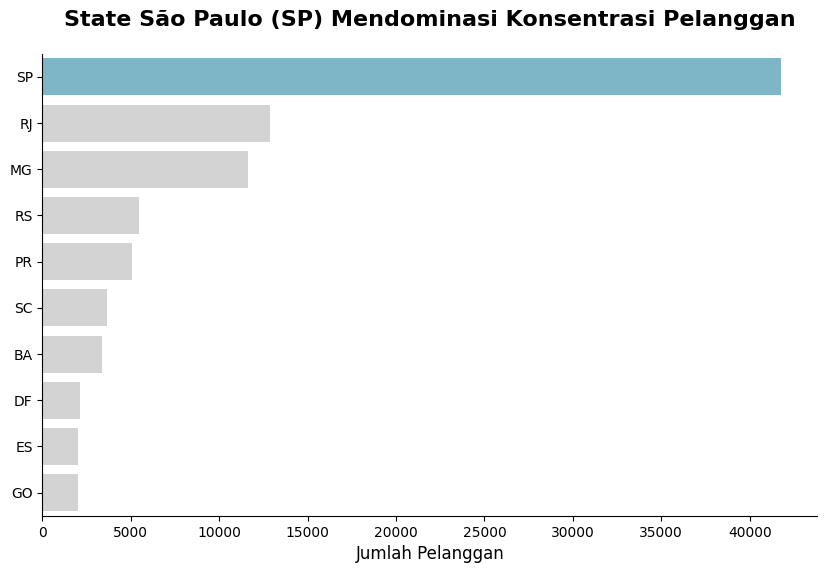

In [442]:
state_counts = customers_df['customer_state'].value_counts().head(10)
colors = ["#72BCD4" if i == 0 else "#D3D3D3" for i in range(len(state_counts))]

plt.figure(figsize=(10, 6))
sns.barplot(
    x=state_counts.values,
    y=state_counts.index,
    hue=state_counts.index,
    palette=colors,
    legend=False
)

plt.title("State São Paulo (SP) Mendominasi Konsentrasi Pelanggan", loc="center", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Jumlah Pelanggan", fontsize=12)
plt.ylabel(None) # Menghilangkan label sumbu Y karena nama State sudah sangat jelas
sns.despine()


plt.show()

**Insight:**

São Paulo (SP) mendominasi pasar secara signifikan dengan jumlah mencapai 40.302 pelanggan, jauh melampaui Rio de Janeiro (12.384) dan Minas Gerais (11.259). Angka ini menunjukkan bahwa aktivitas ekonomi dan basis pengguna kamu masih sangat terpusat di wilayah Tenggara Brazil. Perusahaan sebaiknya memprioritaskan optimasi logistik di area SP untuk efisiensi, namun perlu mulai menyasar wilayah potensial lain agar tidak terlalu bergantung pada satu negara bagian saja.

### Pertanyaan 2: Apa metode pembayaran yang paling populer digunakan oleh pelanggan?

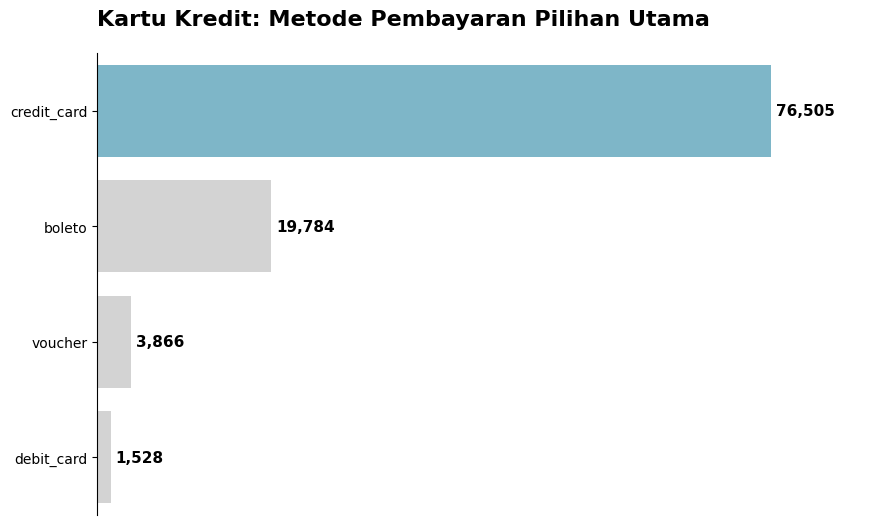

In [443]:
colors = ["#72BCD4" if i == 0 else "#D3D3D3" for i in range(len(payment_order_counts))]

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x=payment_order_counts.values,
    y=payment_order_counts.index,
    hue=payment_order_counts.index,
    palette=colors,
    legend=False
)

for i, v in enumerate(payment_order_counts.values):
    ax.text(v + 500, i, f'{v:,}', va='center', fontsize=11, fontweight='bold')

plt.title("Kartu Kredit: Metode Pembayaran Pilihan Utama", loc="left", fontsize=16, fontweight='bold', pad=20)
plt.xlabel(None)
plt.ylabel(None)
plt.xlim(0, max(payment_order_counts.values) * 1.15)
plt.xticks([])
sns.despine(bottom=True)
plt.show()

**Insight:**

Kartu Kredit menjadi pilihan utama metode pembayaran yang paling mendominasi dengan 76.795 transaksi (lebih dari 70% transaksi), disusul oleh Boleto (19.784) dan Voucher (5.775). Tingginya angka penggunaan kartu kredit mencerminkan preferensi pelanggan terhadap kemudahan transaksi digital dan kemungkinan adanya fitur cicilan. Untuk meningkatkan nilai transaksi, perusahaan bisa memperbanyak promo khusus atau diskon bersama bank penerbit kartu kredit utama.

### Pertanyaan 3: Bagaimana hubungan antara keterlambatan pengiriman dengan tingkat kepuasan pelanggan berdasarkan skor ulasan?

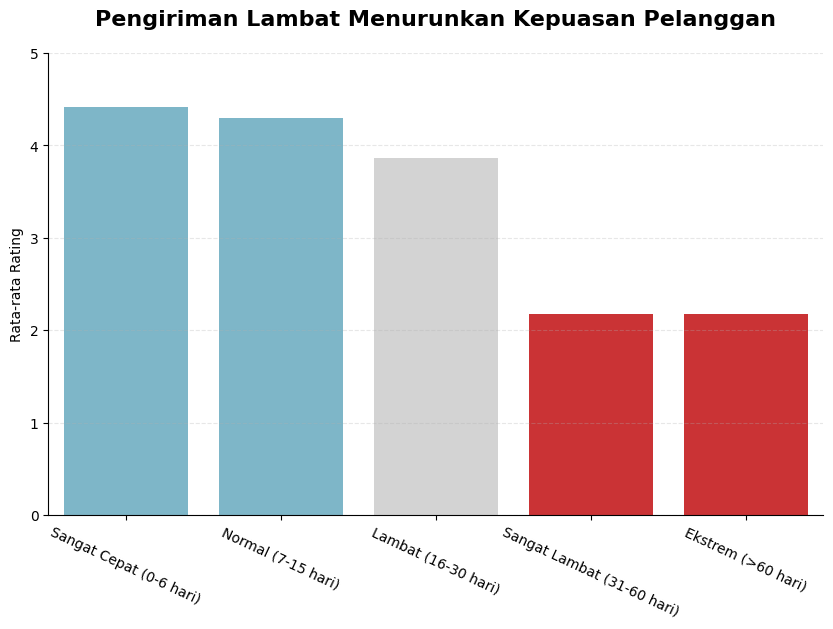

In [444]:
colors = ["#72BCD4", "#72BCD4", "#D3D3D3", "#E31A1C", "#E31A1C"]

plt.figure(figsize=(10, 6))
sns.barplot(
    x='delivery_duration_category',
    y='avg_rating',
    data=rating_analysis,
    hue='delivery_duration_category',
    palette=colors,
    legend=False,
    order=['Sangat Cepat (0-6 hari)', 'Normal (7-15 hari)', 'Lambat (16-30 hari)', 'Sangat Lambat (31-60 hari)', 'Ekstrem (>60 hari)']
)
plt.title("Pengiriman Lambat Menurunkan Kepuasan Pelanggan", fontsize=16, fontweight='bold', pad=20)
plt.xlabel(None)
plt.ylabel("Rata-rata Rating")
plt.ylim(0, 5)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.xticks(rotation=-25)
sns.despine()
plt.show()

**Insight:**

Terdapat penurunan kepuasan pelanggan yang sangat drastis begitu durasi pengiriman melewati ambang batas 30 hari. Data menunjukkan bahwa rating terjaga tinggi di angka ~4.42 untuk pengiriman sangat cepat, namun anjlok hingga ~2.17 pada kategori Sangat Lambat (31-60 hari) dan Ekstrem (>60 hari). Rating pada kedua kategori terlambat tersebut hampir sama mepetnya. Hal ini mengindikasikan bahwa batas toleransi maksimal pelanggan adalah satu bulan. Jika lewat dari itu, kekecewaan pelanggan menjadi tidak terhindarkan.

## Analisis Lanjutan (Opsional)

### Pertanyaan 4: Bagaimana segmentasi pelanggan berdasarkan perilaku pembelian mereka selama periode 2016–2018 menggunakan pendekatan RFM (Recency, Frequency, Monetary)?

Selanjutnya, akan dilakukan segmentasi pelanggan berdasarkan RFM.

Pertama-tama, akan dibuat data frame khusus untuk menilai recency (berdasarkan hari terakhir di dataset + 1 hari), frequency (berdasarkan kemunculan customer_unique_id di berbagai order_id unik), dan monetary (berdasarkan total uang yang digunakan untuk

In [445]:
# 1. Menentukan tanggal referensi untuk menghitung Recency
snapshot_date = customers_orders_payments_df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

# 2. Membuat RFM dataframe
rfm_df = customers_orders_payments_df.groupby(by="customer_unique_id", as_index=False).agg({
    "order_purchase_timestamp": lambda x: (snapshot_date - x.max()).days,
    "order_id": "nunique",
    "payment_value": "sum",
})

# 3. Mengganti nama kolom agar mudah dibaca
rfm_df.columns = ['customer_unique_id', 'recency', 'frequency', 'monetary']

# Tampilkan 5 data teratas
rfm_df.head()

,customer_unique_id,recency,frequency,monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19
2,0000f46a3911fa3c0805444483337064,537,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89


In [446]:
rfm_df.describe()

,recency,frequency,monetary
count,93335.000000,93335.000000,93335.000000
mean,237.898752,1.033417,165.199917
std,152.545822,0.209099,226.335837
min,1.000000,1.000000,9.590000
25%,114.000000,1.000000,63.050000
50%,219.000000,1.000000,107.780000
75%,346.000000,1.000000,182.545000
max,695.000000,15.000000,13664.080000


In [447]:
rfm_df.sort_values(by="recency", ascending=True).head(5)

,customer_unique_id,recency,frequency,monetary
25143,44d111bdc55faca551ef91cb74a444d8,1,1,259.81
61028,a712a430955027da5bc257a10073a390,1,1,161.97
1510,0421e7a23f21e5d54efed456aedbc513,1,1,119.42
16338,2cbb27285e259123d5b9aac321b7085e,1,1,216.58
71657,c45221bb4573f66bdd4daf43fe2d4b3b,1,1,37.37


In [448]:
rfm_df.sort_values(by="frequency", ascending=False).head(5)

,customer_unique_id,recency,frequency,monetary
51420,8d50f5eadf50201ccdcedfb9e2ac8455,9,15,879.27
22774,3e43e6105506432c953e165fb2acf44c,183,9,1172.66
73904,ca77025e7201e3b30c44b472ff346268,90,7,1122.72
36700,6469f99c1f9dfae7733b25662e7f1782,63,7,758.83
10058,1b6c7548a2a1f9037c1fd3ddfed95f33,197,7,959.01


In [449]:
rfm_df.sort_values(by="monetary", ascending=False).head(5)

,customer_unique_id,recency,frequency,monetary
3724,0a0a92112bd4c708ca5fde585afaa872,334,1,13664.08
79616,da122df9eeddfedc1dc1f5349a1a690c,515,2,7571.63
43161,763c8b1c9c68a0229c42c9fc6f662b93,46,1,7274.88
80443,dc4802a71eae9be1dd28f5d788ceb526,563,1,6929.31
25431,459bef486812aa25204be022145caa62,35,1,6922.21


Selanjutnya, setiap metrik RFM akan dinormalisasikan ke dalam rank, mengingat distribusinya yang sangat lebar dan tidak simetris. Rank juga akan diskalakan dari 0-100.

In [450]:
# Menghitung rank untuk setiap metrik RFM
rfm_df['r_rank'] = rfm_df['recency'].rank(ascending=False)
rfm_df['f_rank'] = rfm_df['frequency'].rank(ascending=True)
rfm_df['m_rank'] = rfm_df['monetary'].rank(ascending=True)

# Normalisasi rank ke skala 0-100
rfm_df['r_rank_norm'] = (rfm_df['r_rank'] / rfm_df['r_rank'].max()) * 100
rfm_df['f_rank_norm'] = (rfm_df['f_rank'] / rfm_df['f_rank'].max()) * 100
rfm_df['m_rank_norm'] = (rfm_df['m_rank'] / rfm_df['m_rank'].max()) * 100

rfm_df = rfm_df.drop(columns=['r_rank', 'f_rank', 'm_rank'])

rfm_df.head()

,customer_unique_id,recency,frequency,monetary,r_rank_norm,f_rank_norm,m_rank_norm
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90,75.852702,48.500562,63.460117
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19,74.804171,48.500562,2.172283
2,0000f46a3911fa3c0805444483337064,537,1,86.22,3.490104,48.500562,39.450903
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62,28.631283,48.500562,12.252103
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89,33.657483,48.500562,77.995929


Selanjutnya, akan dibuat skor RFM tunggal yang berasal dari pembobotan setiap metrik RFM. Monetary akan diprioritaskan (60%) karena menggambarkan revenue secara langsung. Frequency menempati posisi kedua (25%) dan disusul oleh recency (15%) untuk memperhitungkan pelanggan yang sudah sering berbelanja dan orang yang belum lama ini berbelanja.

In [451]:
# Menghitung RFM Score dengan bobot: R=15%, F=25%, M=60%
# Hasil akhir diskalakan menjadi 0-5
rfm_df['RFM_score'] = (0.15 * rfm_df['r_rank_norm'] +
                       0.25 * rfm_df['f_rank_norm'] +
                       0.60 * rfm_df['m_rank_norm']) * 0.05

rfm_df = rfm_df.round(2)
rfm_df[['customer_unique_id', 'RFM_score']].head()

,customer_unique_id,RFM_score
0,0000366f3b9a7992bf8c76cfdf3221e2,3.08
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1.23
2,0000f46a3911fa3c0805444483337064,1.82
3,0000f6ccb0745a6a4b88665a16c9f078,1.19
4,0004aac84e0df4da2b147fca70cf8255,3.20


In [452]:
rfm_df['RFM_score'].describe()

,RFM_score
count,93335.000000
mean,2.500076
std,0.919141
min,0.610000
25%,1.730000
50%,2.490000
75%,3.260000
max,4.970000


Selanjutnya, akan dilakukan segmentasi pelanggan berdasarkan scoring RFM yang sudah diskalakan 1-5. Pelanggan dikelompokkan ke dalam lima segmen strategis. Pembagian ini menggunakan titik potong (*threshold*) yang disesuaikan dengan distribusi skor untuk membedakan karakteristik setiap kelompok sebagai berikut:

* **Top Customers (Skor > 4,5):** Kelompok elit yang memiliki nilai transaksi tertinggi dan keaktifan belanja yang baik.
* **High Value Customer (Skor > 4,0):** Pelanggan potensial yang memiliki kontribusi ekonomi di atas rata-rata.
* **Medium Value Customer (Skor > 3,0):** Kelompok pelanggan menengah yang memiliki tingkat aktivitas moderat.
* **Low Value Customers (Skor > 1,6):** Pelanggan dengan riwayat transaksi yang kecil atau sudah jarang aktif.
* **Lost Customers (Skor < 1,6):** Pelanggan dengan performa terendah yang terindikasi sudah tidak kembali bertransaksi (*churn*).

In [453]:
# Menentukan kategori segmen berdasarkan skor
rfm_df["customer_segment"] = np.where(rfm_df['RFM_score'] > 4.5, "Top customers",
                             np.where(rfm_df['RFM_score'] > 4, "High value customer",
                             np.where(rfm_df['RFM_score'] > 3, "Medium value customer",
                             np.where(rfm_df['RFM_score'] > 1.6, 'Low value customers', 'lost customers'))))

# Membuat urutan kategori agar visualisasi rapi
rfm_df['customer_segment'] = pd.Categorical(rfm_df['customer_segment'], [
    "lost customers", "Low value customers", "Medium value customer",
    "High value customer", "Top customers"
])

rfm_df[['customer_unique_id', 'RFM_score', 'customer_segment']].head(10)

,customer_unique_id,RFM_score,customer_segment
0,0000366f3b9a7992bf8c76cfdf3221e2,3.08,Medium value customer
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1.23,lost customers
2,0000f46a3911fa3c0805444483337064,1.82,Low value customers
3,0000f6ccb0745a6a4b88665a16c9f078,1.19,lost customers
4,0004aac84e0df4da2b147fca70cf8255,3.20,Medium value customer
5,0004bd2a26a76fe21f786e4fbd80607f,3.25,Medium value customer
6,00050ab1314c0e55a6ca13cf7181fecf,1.34,lost customers
7,00053a61a98854899e70ed204dd4bafe,3.86,Medium value customer
8,0005e1862207bf6ccc02e4228effd9a0,2.62,Low value customers
9,0005ef4cd20d2893f0d9fbd94d3c0d97,2.84,Low value customers


In [454]:
# Menghitung banyaknya pelanggan dari setiap segment
segment_counts = rfm_df['customer_segment'].value_counts()

segment_counts.sort_index(ascending=False)

,count
customer_segment,
Top customers,494
High value customer,3376
Medium value customer,27238
Low value customers,42901
lost customers,19326


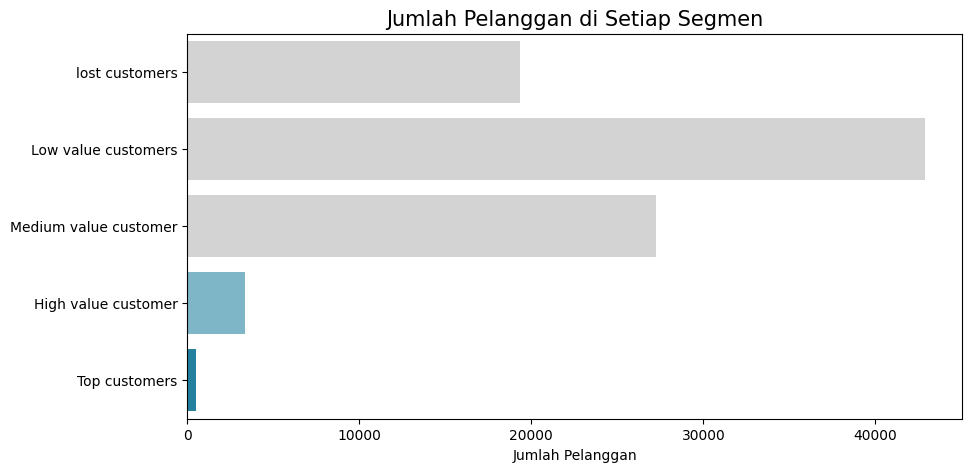

In [455]:
customer_segment_df = rfm_df.groupby(by="customer_segment", as_index=False, observed=False).customer_unique_id.nunique()

plt.figure(figsize=(10, 5))
colors_ = ["#D3D3D3", "#D3D3D3", "#D3D3D3", "#72BCD4", "#118AB2"]

sns.barplot(
    x="customer_unique_id",
    y="customer_segment",
    data=customer_segment_df.sort_values(by="customer_segment", ascending=False),
    palette=colors_,
    hue="customer_segment",
    legend=False
)
plt.title("Jumlah Pelanggan di Setiap Segmen", loc="center", fontsize=15)
plt.ylabel(None)
plt.xlabel("Jumlah Pelanggan")
plt.show()

Berdasarkan hasil segmentasi, komposisi basis pelanggan perusahaan selama periode 2016–2018 menunjukkan struktur sebagai berikut:
- Mayoritas pelanggan berada pada kelompok Low Value Customers (42.901 orang) dan Medium Value Customer (27.238 orang). Hal ini mencerminkan karakteristik pasar yang luas dengan basis massa yang besar namun bersifat transaksional.
- Terdapat 19.326 pelanggan yang masuk dalam kategori Lost Customers. Angka ini cukup signifikan (sekitar 20%) dan menjadi indikator penting bagi perusahaan untuk mengevaluasi penyebab pelanggan tidak kembali berbelanja.
- Segmen Top Customers berjumlah 494 orang. Meskipun jumlahnya sangat sedikit, kelompok ini merupakan pelanggan yang paling loyal dan aktif, sehingga perlu dijaga melalui strategi retensi yang lebih personal.

### Pertanyaan 5: Bagaimana kontribusi masing-masing segmen pelanggan terhadap total revenue selama periode analisis?

Selanjutnya akan ditentukan kontribusi revenue (total monetary) pada setiap segment. Hal ini untuk memberi gambaran kontribusi setiap segment terhadap pendapatan perusahaan.

In [456]:
# Menampilkan total revenue dari masing-masing segment
revenue_segment_df = rfm_df.groupby(by="customer_segment", as_index=False, observed=False).monetary.sum()
revenue_segment_df.sort_index(ascending=False)

,customer_segment,monetary
4,Top customers,305107.14
3,High value customer,2209232.38
2,Medium value customer,7854728.70
1,Low value customers,4235576.31
0,lost customers,814289.74


In [457]:
#Rata-rata pengeluaran tiap customer dari masing-masing segment
customer_segment_average_df = rfm_df.groupby(by="customer_segment", as_index=False, observed=False).monetary.mean()
customer_segment_average_df.sort_index(ascending=False)

,customer_segment,monetary
4,Top customers,617.625789
3,High value customer,654.393477
2,Medium value customer,288.373915
1,Low value customers,98.729081
0,lost customers,42.134417


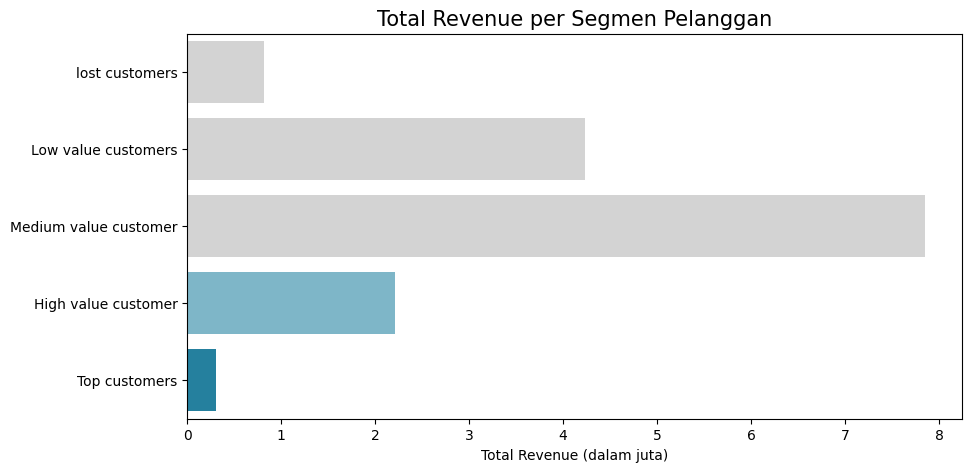

In [458]:
# Membagi nilai monetary menjadi satuan juta (10^6)
revenue_segment_df["monetary_million"] = revenue_segment_df["monetary"] / 10**6

#Membuat Visualisasi
plt.figure(figsize=(10, 5))
sns.barplot(
    x="monetary_million",
    y="customer_segment",
    data=revenue_segment_df.sort_values(by="customer_segment", ascending=False),
    palette=colors_,
    hue="customer_segment",
    legend=False
)
plt.title("Total Revenue per Segmen Pelanggan", loc="center", fontsize=15)
plt.ylabel(None)
plt.xlabel("Total Revenue (dalam juta)")
plt.show()

Meskipun jumlah pelanggan didominasi oleh segmen bawah, kontribusi terhadap total pendapatan menunjukkan pola yang berbeda:
- Segmen Medium Value Customer menyumbang pendapatan terbesar, yaitu mencapai 7.854.728,70. Kelompok ini adalah penggerak utama ekonomi perusahaan karena memiliki keseimbangan antara jumlah orang dan nilai transaksi.
- Segmen Low Value Customers menempati posisi kedua dengan kontribusi sebesar 4.235.576,31. Hal ini membuktikan bahwa meskipun nilai per transaksinya kecil, volume pelanggan yang sangat besar tetap memberikan dampak finansial yang signifikan bagi platform.
- Segmen High Value (2.209.232,38) dan Top Customers (305.107,14) memberikan kontribusi yang stabil. Segmen Top Customers adalah yang paling efisien karena menyumbang nilai ekonomi besar dengan jumlah individu yang sangat sedikit, sehingga biaya pengelolaan (maintenance) per pelanggan menjadi lebih efektif.

## Conclusion


- Conclusion Pertanyaan 1: Pelanggan terkonsentrasi secara masif di wilayah Tenggara (Southeast) Brazil, dengan negara bagian **Sao Paulo (SP)** sebagai pusat konsentrasi utama, diikuti oleh Rio de Janeiro (RJ) dan Minas Gerais (MG). Hal ini menunjukkan adanya sentralisasi pasar di wilayah dengan infrastruktur ekonomi yang lebih maju.

- Conclusion Pertanyaan 2: Metode pembayaran yang paling populer dan mendominasi adalah **Credit Card**, disusul oleh **Boleto**. Penggunaan kartu kredit yang tinggi menunjukkan preferensi pelanggan terhadap kemudahan transaksi digital dan fitur pembayaran cicilan.

- Conclusion Pertanyaan 3: Terdapat hubungan **korelasi negatif** yang kuat antara keterlambatan pengiriman dengan kepuasan pelanggan. Semakin lama waktu pengiriman melebihi estimasi, semakin rendah skor ulasan yang diberikan pelanggan. Ketepatan waktu pengiriman adalah faktor kunci dalam menjaga *Review Score*.

- Conclusion Pertanyaan 4: Melalui pendekatan *Weighted RFM*, pelanggan terbagi menjadi lima segmen strategis. Basis pelanggan bersifat sangat transaksional, di mana mayoritas populasi (~88%) berada pada kategori **Low Value** dan **Medium Value**, sementara segmen **Top Customers** merupakan kelompok elit yang sangat kecil namun paling setia.

- Conclusion Pertanyaan 5: Kontribusi pendapatan terbesar berasal dari segmen **Medium Value** (sebagai tulang punggung ekonomi) dan **Low Value** (karena volume jumlah pelanggan yang sangat besar). Meskipun demikian, segmen **Top Customers** memiliki nilai efisiensi tertinggi dengan rata-rata pengeluaran per individu yang jauh melampaui rata-rata populasi.